# Analyzing Lung Sounds Datasets

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
import random
random.seed(42)

import pandas as pd
from matplotlib import pyplot as plt

from dataset import ICBHIDataset, FraiwanDataset
from dataset.transforms import (
    SpectrogramTransform,
    MelSpectrogramTransform,
    MFCCTransform,
    MFCCDeltaTransform,
    ChromaTransform,
    SpectralContrastTransform,
    CQTSpectrogramTransform,
    PhaseTransform,
)

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), "data")
if not os.path.exists(data_path):
    print(f"Data directory not found at {data_path}. Please ensure the data is downloaded and placed in the correct location.")

## ICBHI 2017

In [3]:
icbhi_dataset = ICBHIDataset(data_path)
print(f"Dataset size: {len(icbhi_dataset)} samples")
icbhi_dataset.data.head()

Dataset size: 920 samples


,FilePath,Label,FileName,PatientNumber,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment
0,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,101_1b1_Al_sc_Meditron,101,1b1,Al,sc,Meditron
1,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,101_1b1_Pr_sc_Meditron,101,1b1,Pr,sc,Meditron
2,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,102_1b1_Ar_sc_Meditron,102,1b1,Ar,sc,Meditron
3,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,103_2b2_Ar_mc_LittC2SE,103,2b2,Ar,mc,LittC2SE
4,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,104_1b1_Al_sc_Litt3200,104,1b1,Al,sc,Litt3200


Sample 50:
  File path: /home/leticialopes/projects/IA901/IA901_Project/data/ICBHI_final_database/110_1p1_Ll_sc_Meditron.wav
  Sample rate: 4000
  Audio shape: (129600,)
  Label: COPD


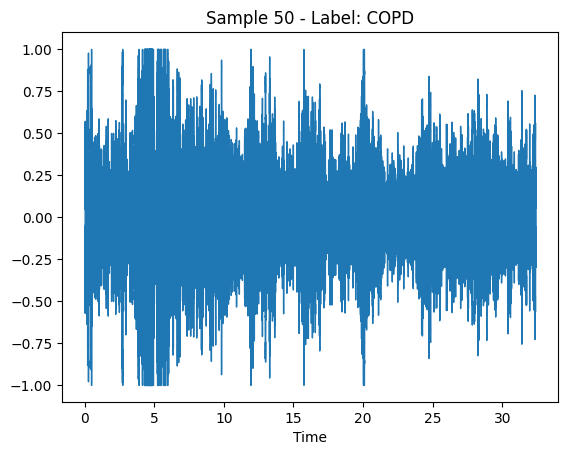

In [4]:
# Test loading a sample
icbhi_dataset.unit_test(idx=50)

### Class Distribution

Label
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

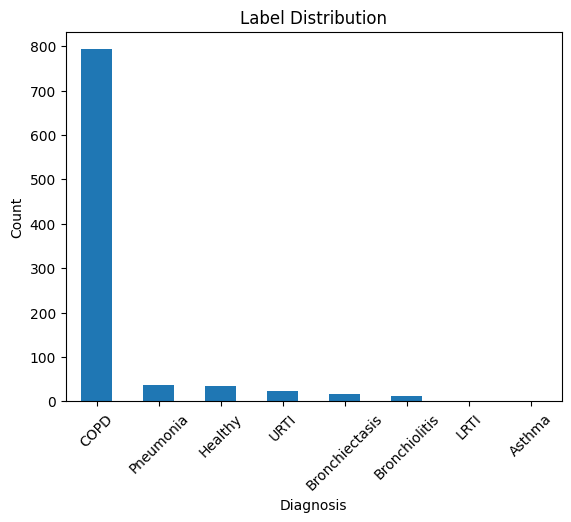

In [5]:
def plot_label_distribution(data):
    """Plot the distribution of labels in the dataset."""
    label_counts = data["Label"].value_counts()
    label_counts.plot(kind="bar")
    display(label_counts)
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

plot_label_distribution(icbhi_dataset.data)

In [6]:
def get_samples_by_label(dataset):
    """Get one sample for each label in the dataset."""
    samples = {}
    for label in sorted(dataset.data["Label"].unique()):
        label_samples = dataset.data[dataset.data["Label"] == label]
        random_idx = random.randint(0, len(label_samples) - 1)
        samples[label] = random_idx
    return samples

SAMPLES = get_samples_by_label(icbhi_dataset)
print("Sampled records:")
for label, sample in SAMPLES.items():
    print(f"Label: {label}, Sample: {sample}")

Sampled records:
Label: Asthma, Sample: 0
Label: Bronchiectasis, Sample: 0
Label: Bronchiolitis, Sample: 11
Label: COPD, Sample: 281
Label: Healthy, Sample: 15
Label: LRTI, Sample: 0
Label: Pneumonia, Sample: 8
Label: URTI, Sample: 3


## Audio Transforms - Feature Extraction

O módulo `dataset.transforms` permite extrair diferentes representações de áudio.

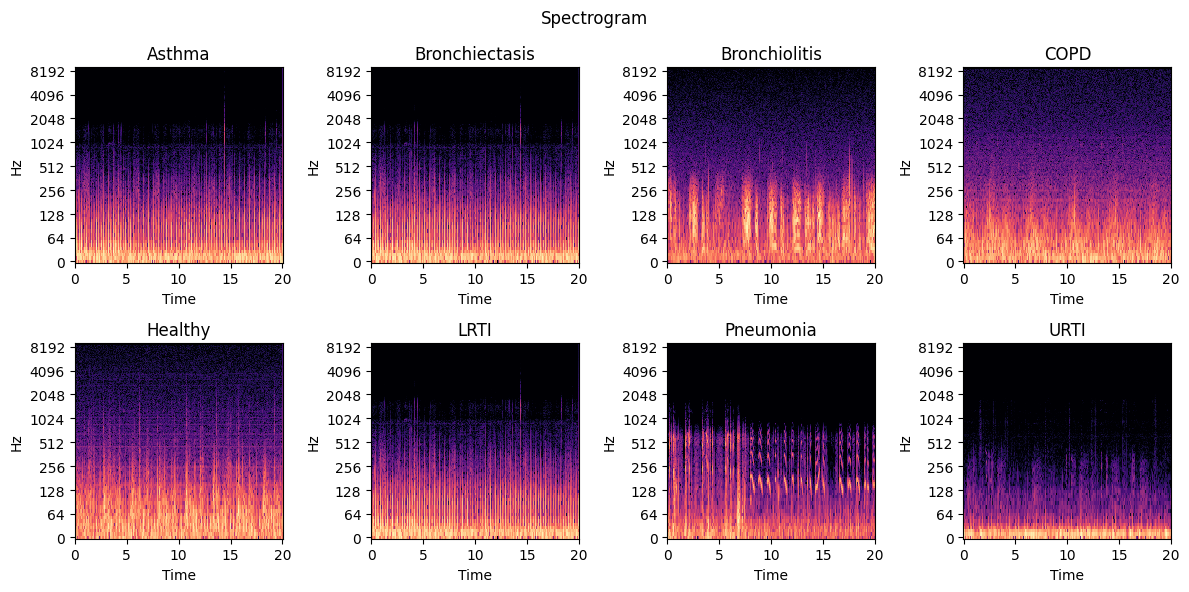

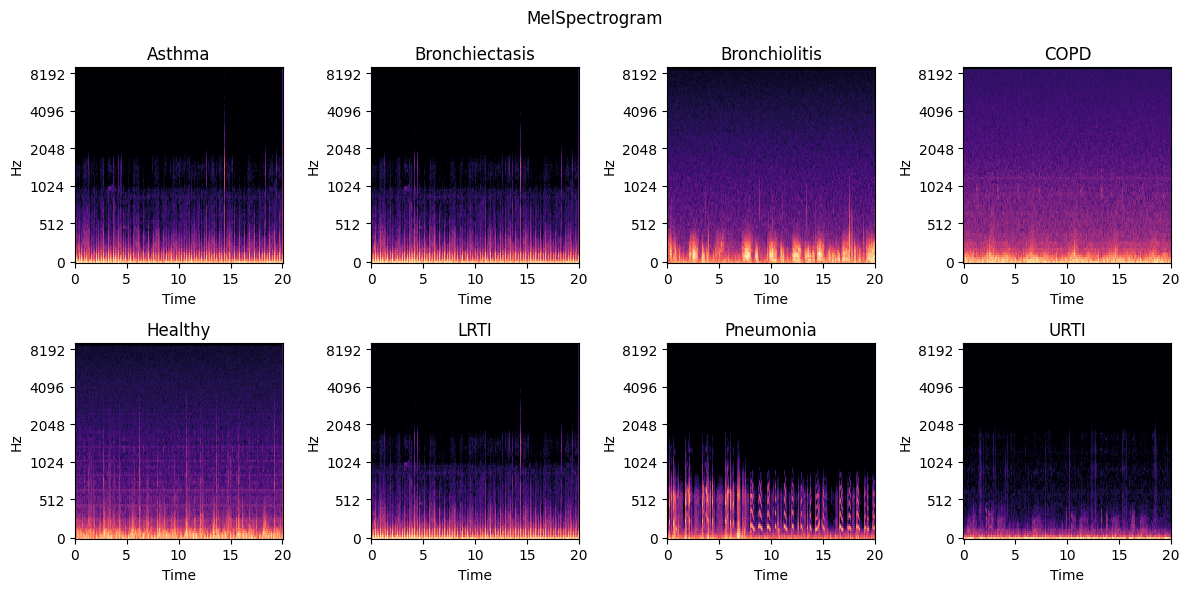

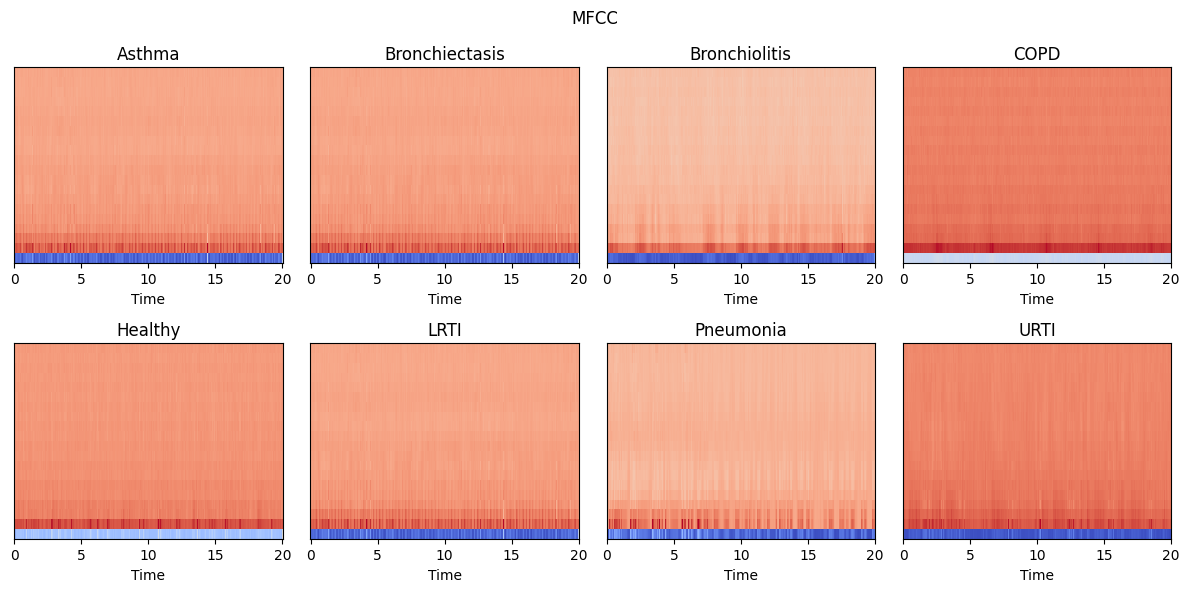

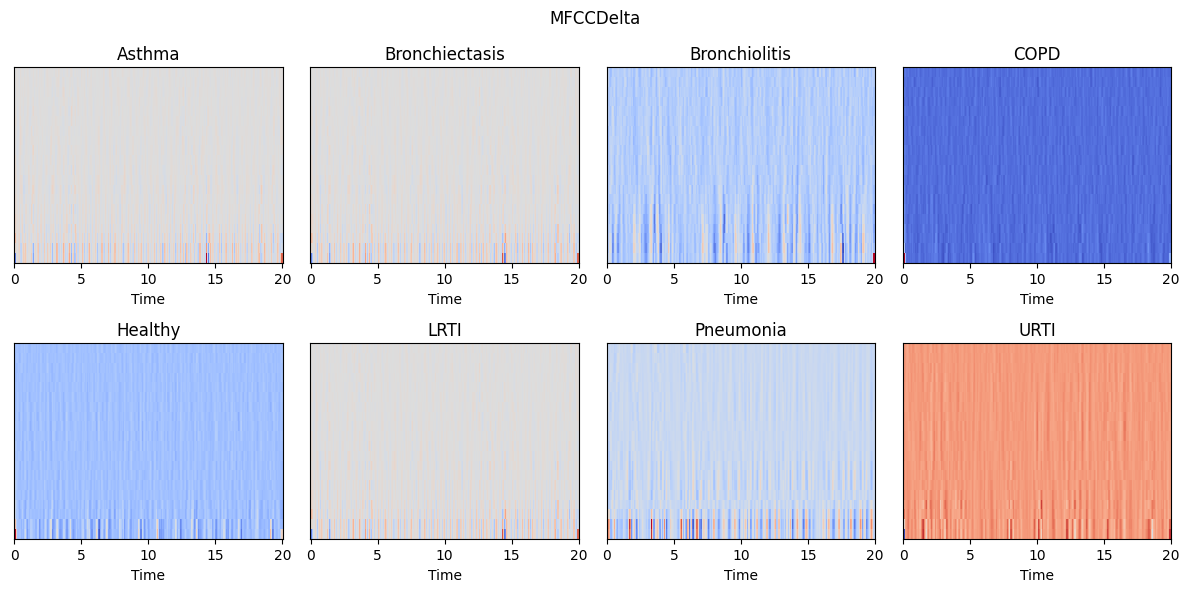

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


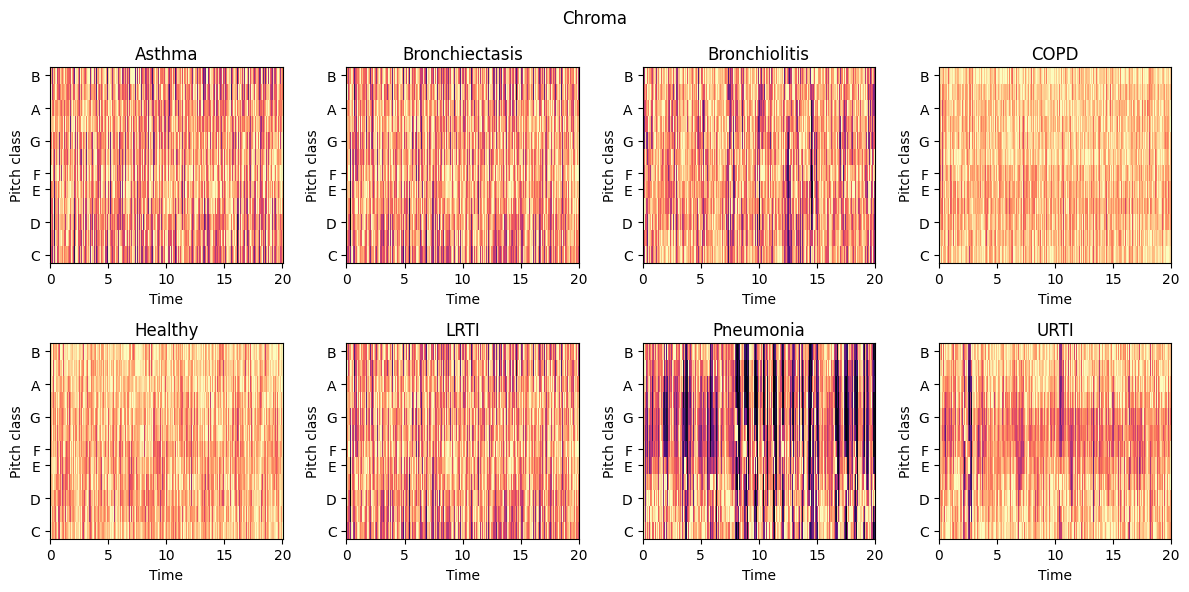

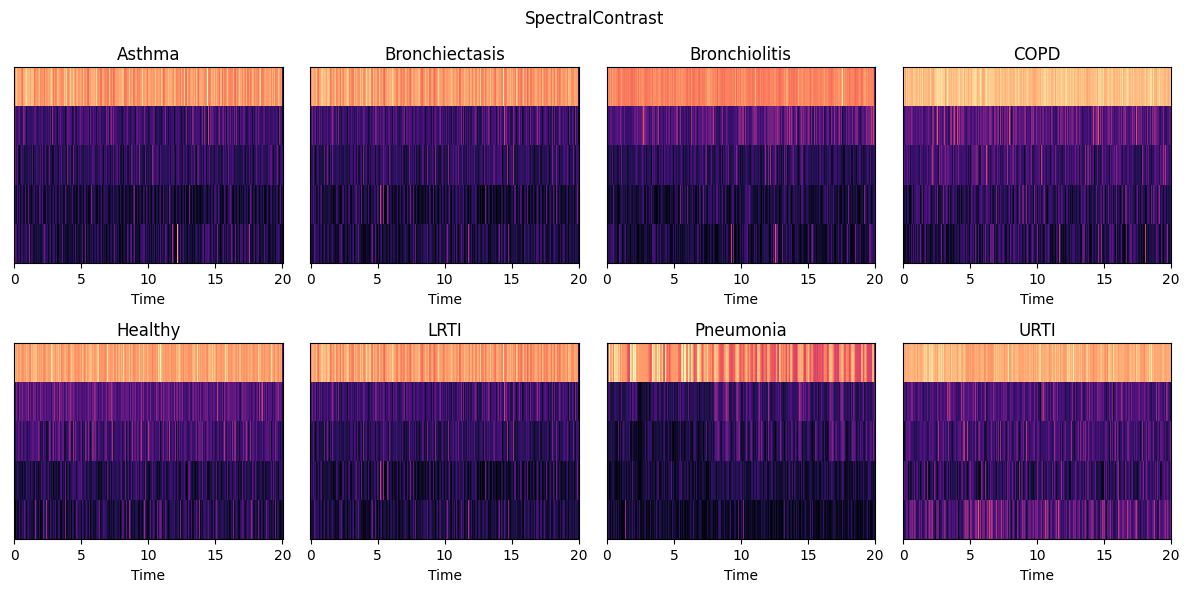

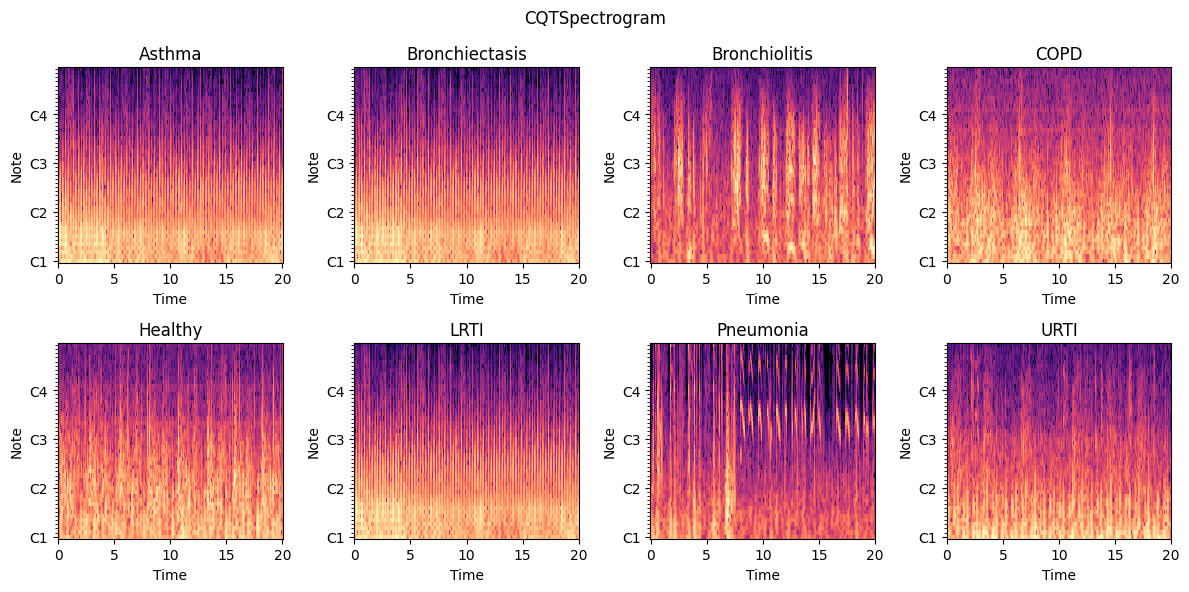

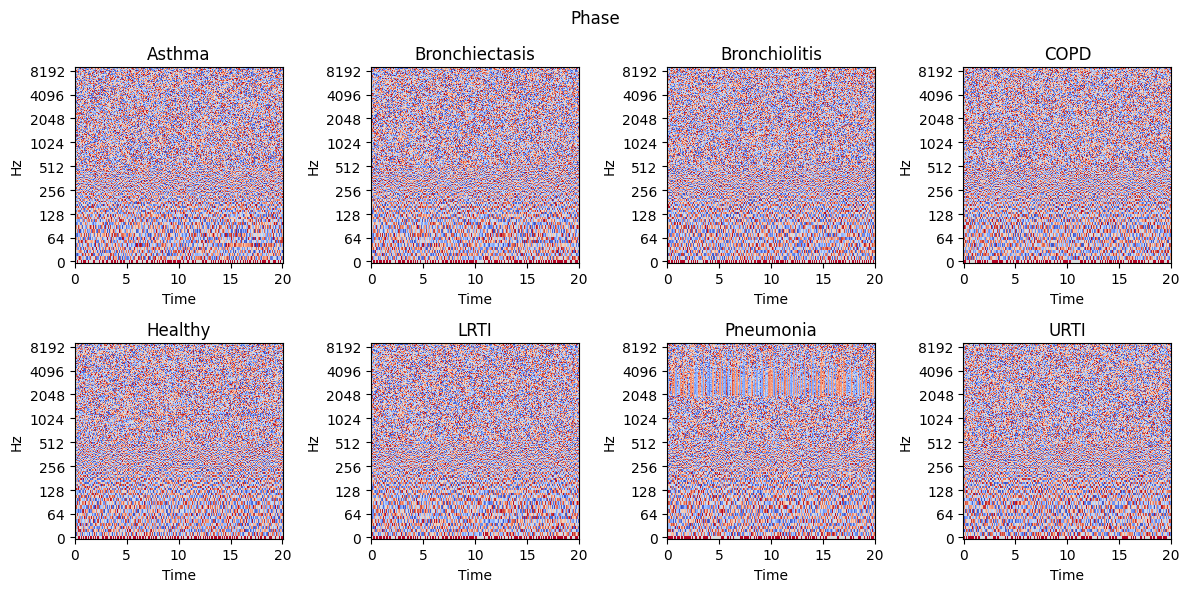

In [7]:
TARGET_SR = 18000
TARGET_DURATION = 20

transformations = {
    "Spectrogram": SpectrogramTransform(),
    "MelSpectrogram": MelSpectrogramTransform(n_mels=128),
    "MFCC": MFCCTransform(n_mfcc=20),
    "MFCCDelta": MFCCDeltaTransform(n_mfcc=20),
    "Chroma": ChromaTransform(),
    "SpectralContrast": SpectralContrastTransform(n_bands=4, fmin=50),
    "CQTSpectrogram": CQTSpectrogramTransform(n_bins=48, fmin=30, bins_per_octave=12),
    "Phase": PhaseTransform(),
}

for name, transform in transformations.items():
    # 8 classes
    figure, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    for i, (label, idx) in enumerate(SAMPLES.items()):
        dataset = ICBHIDataset(data_path, transform=transform, standardize=True, target_sr=TARGET_SR, target_duration=TARGET_DURATION)
        ax = axes[i]
        sample, sr = dataset[idx]

        if name in ["Spectrogram", "Phase"]:
            y_axis = 'log'
        elif name in ["MelSpectrogram"]:
            y_axis = 'mel'
        elif name in ["Chroma"]:
            y_axis = 'chroma'
        elif name in ["CQTSpectrogram"]:
            y_axis = 'cqt_note'
        else:
            y_axis = None

        sample.plot_audio(title=f"{label}", y_axis=y_axis, ax=ax)
    figure.suptitle(f"{name}")
    plt.tight_layout()
    plt.show()

In [9]:
fraiwan_dataset = FraiwanDataset(data_path)
print(f"Dataset size: {len(fraiwan_dataset)} samples")
fraiwan_dataset.data.head()

Dataset size: 243 samples


,FilePath,Label,RawDiagnosis,FileName,FilterCode,FilterType,PatientNumber,Diagnosis
0,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,N,"BP100_N,N,P R M,70,F",B,Bell (20-200 Hz),P100,"N,N,P R M,70,F"
1,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,Asthma,"BP101_Asthma,E W,P L M,12,F",B,Bell (20-200 Hz),P101,"Asthma,E W,P L M,12,F"
2,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,N,"BP102_N,N,P L L,41,M",B,Bell (20-200 Hz),P102,"N,N,P L L,41,M"
3,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,N,"BP103_N,N,P R U,81,F",B,Bell (20-200 Hz),P103,"N,N,P R U,81,F"
4,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,Asthma,"BP104_Asthma,E W,P L U,45,F",B,Bell (20-200 Hz),P104,"Asthma,E W,P L U,45,F"


In [12]:
SAMPLES = get_samples_by_label(fraiwan_dataset)
print("Sampled records:")
for label, sample in SAMPLES.items():
    print(f"Label: {label}, Sample: {sample}")

Sampled records:
Label: Asthma, Sample: 11
Label: COPD, Sample: 6
Label: Healthy, Sample: 29
Label: Pneumonia, Sample: 8


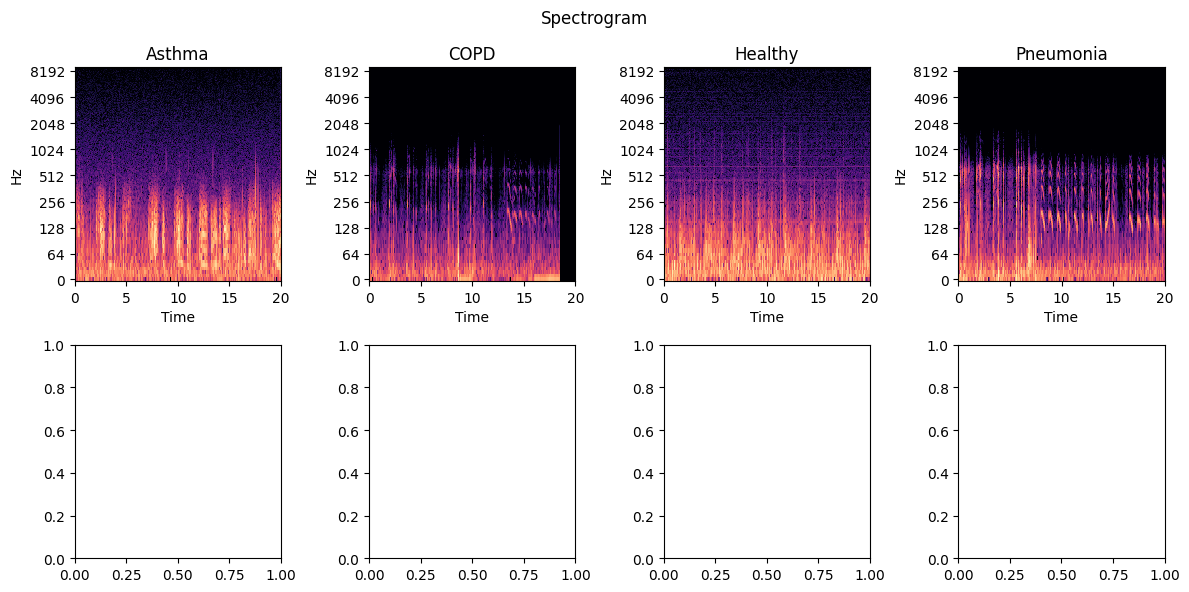

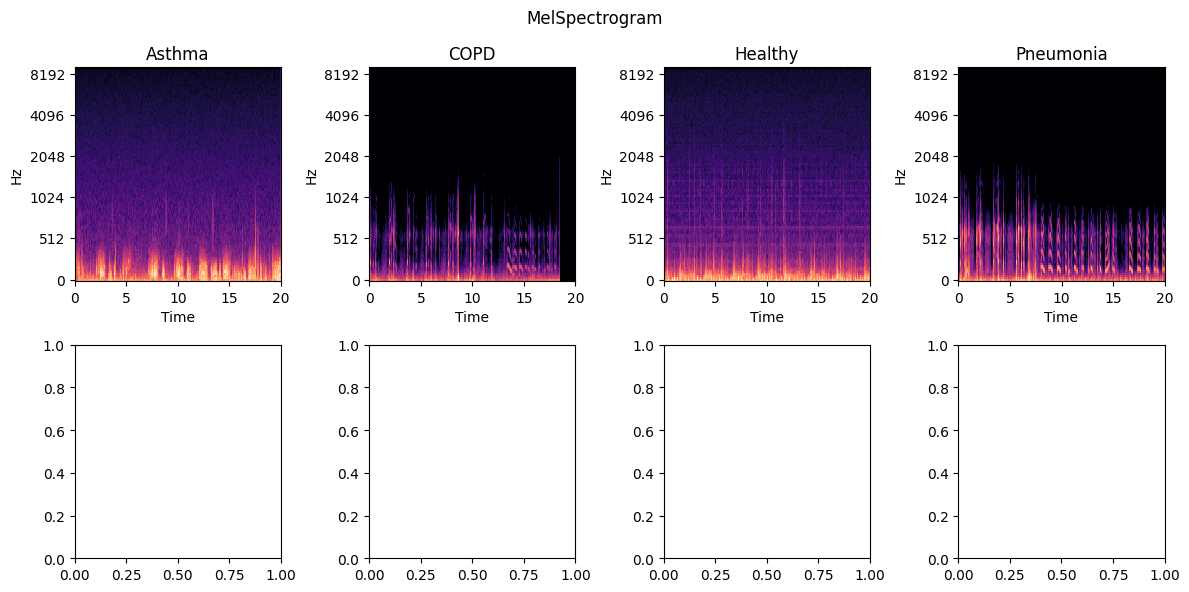

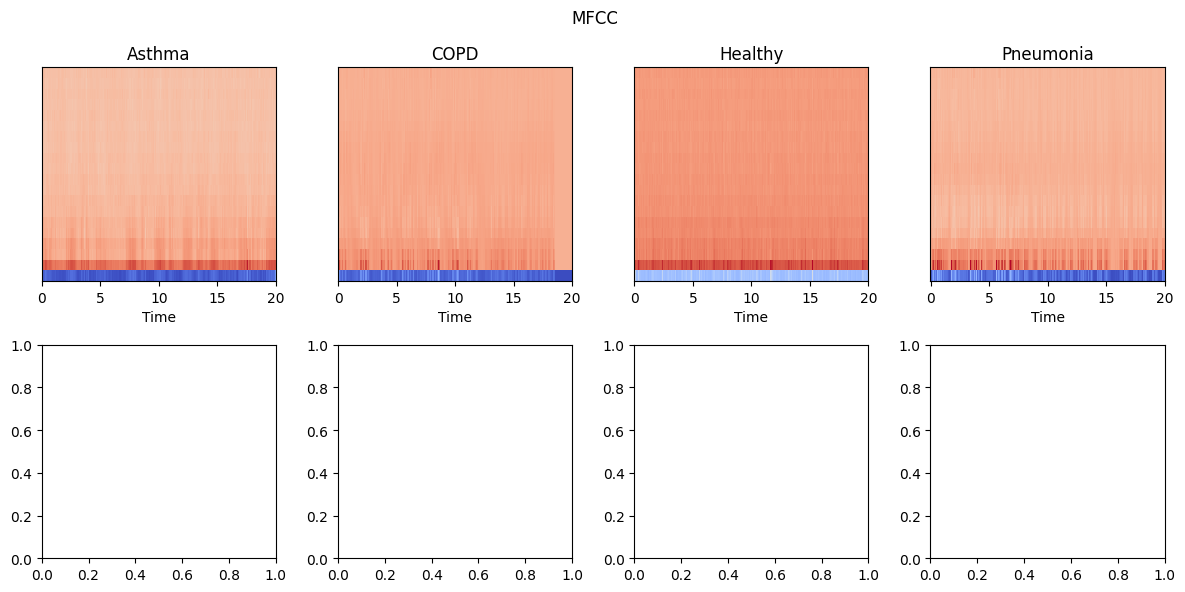

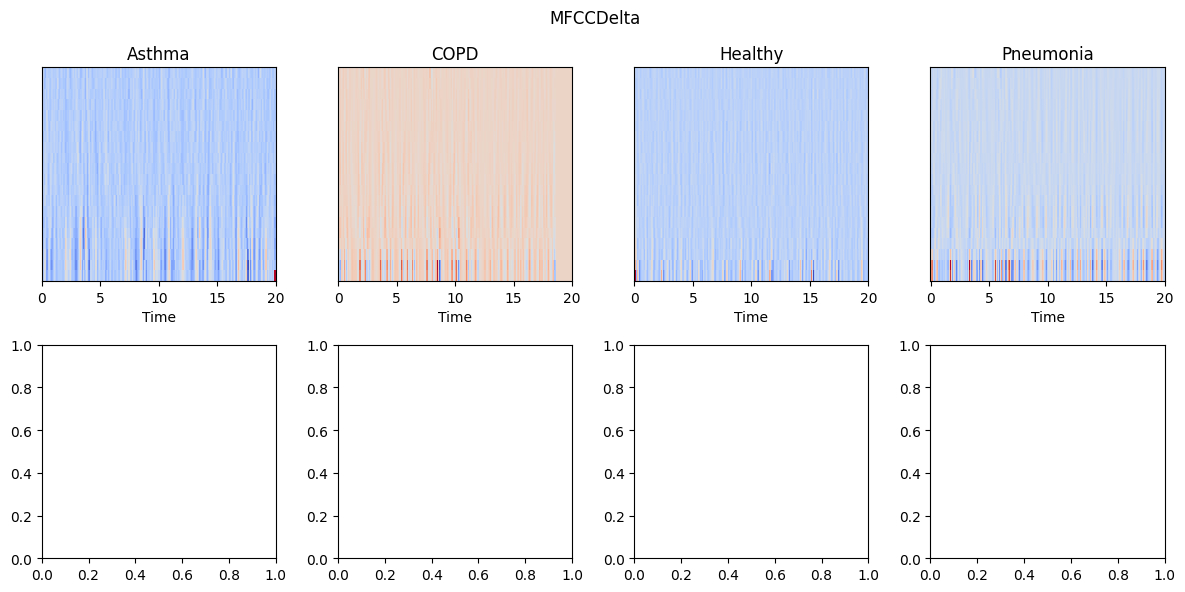

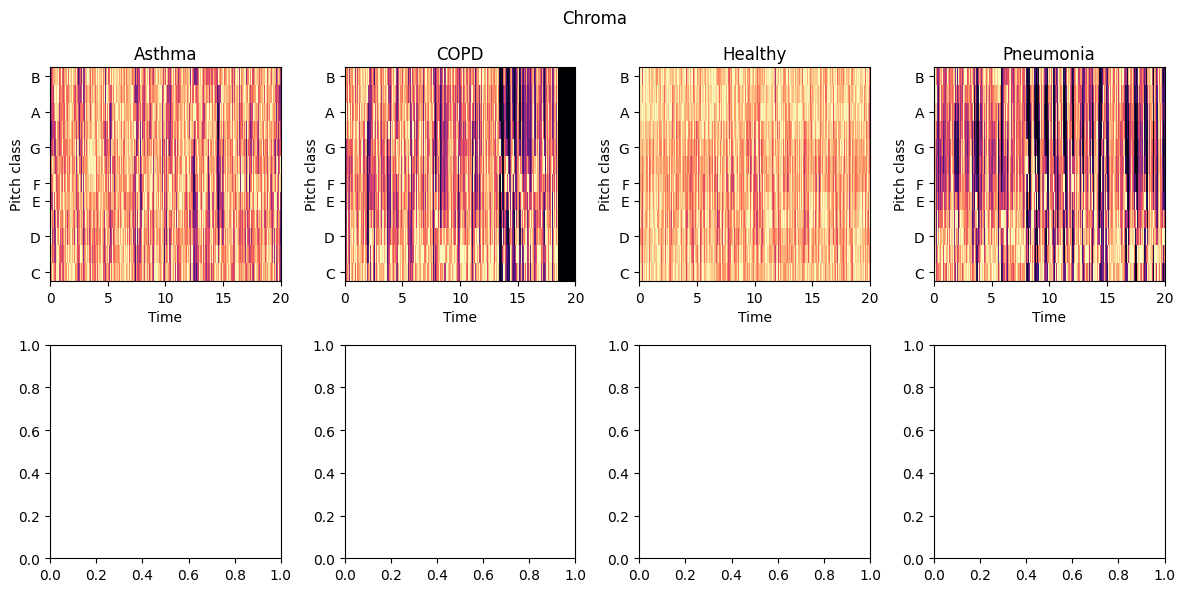

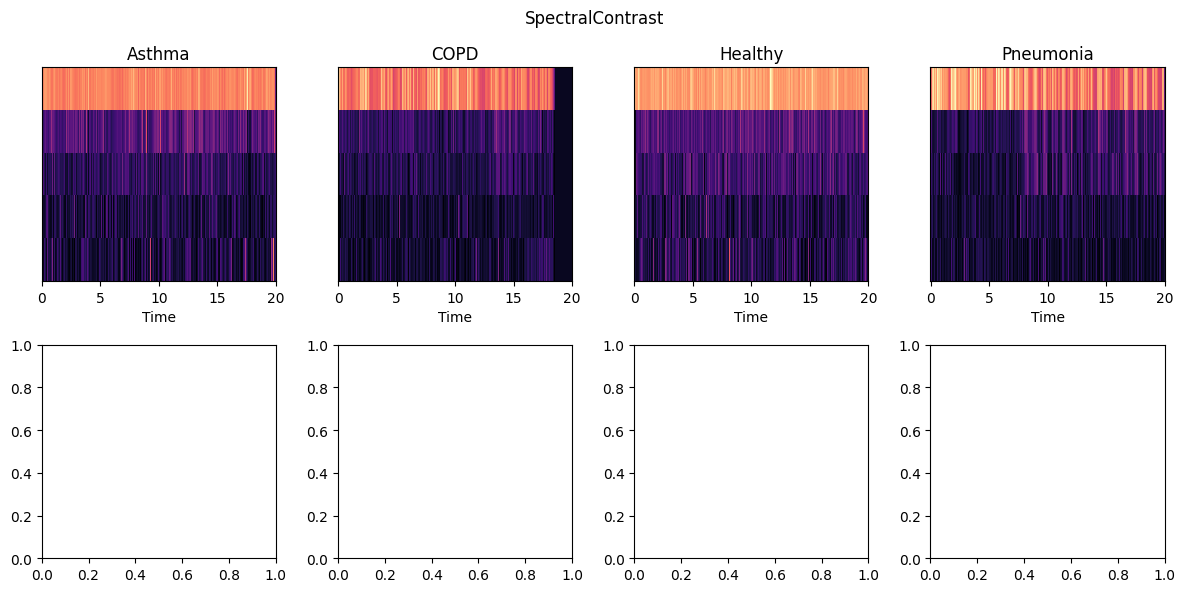

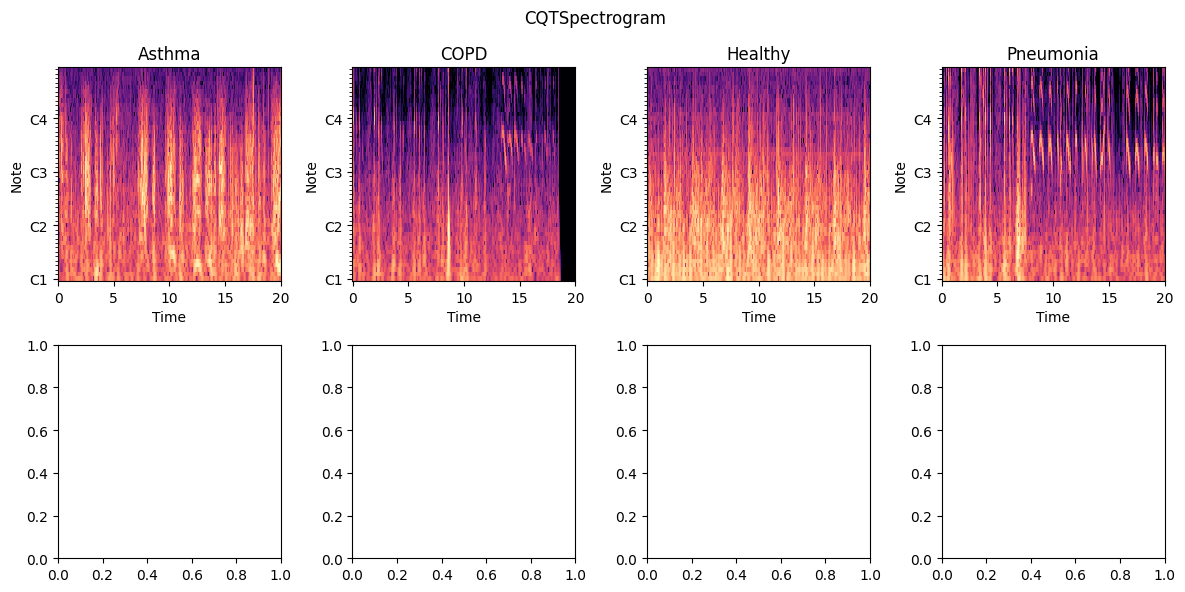

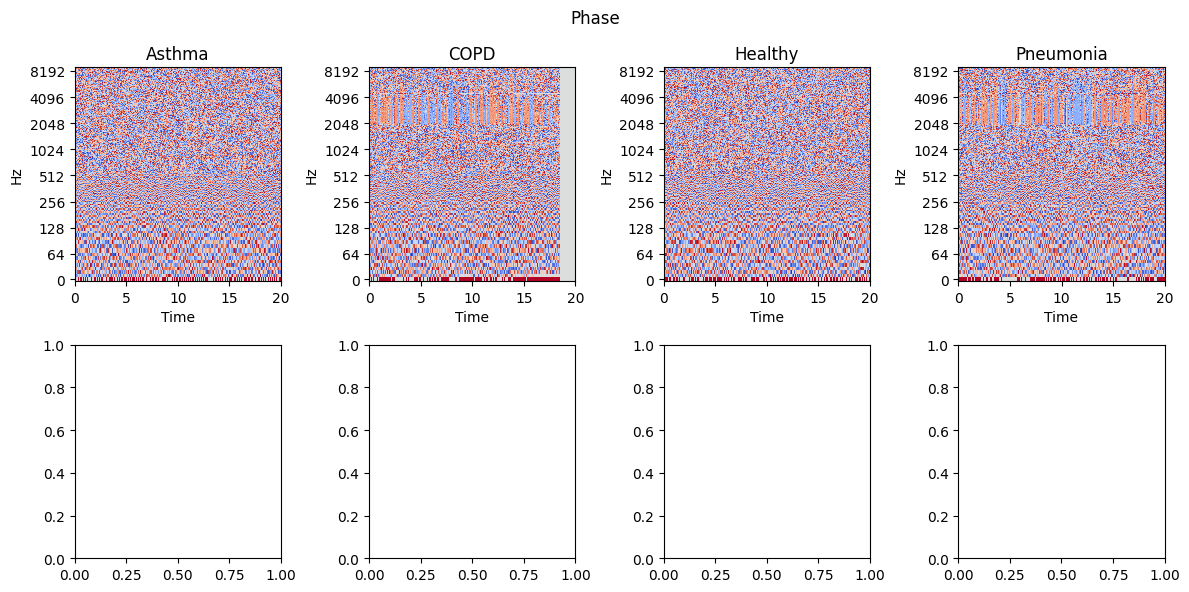

In [13]:
TARGET_SR = 18000
TARGET_DURATION = 20

transformations = {
    "Spectrogram": SpectrogramTransform(),
    "MelSpectrogram": MelSpectrogramTransform(n_mels=128),
    "MFCC": MFCCTransform(n_mfcc=20),
    "MFCCDelta": MFCCDeltaTransform(n_mfcc=20),
    "Chroma": ChromaTransform(),
    "SpectralContrast": SpectralContrastTransform(n_bands=4, fmin=50),
    "CQTSpectrogram": CQTSpectrogramTransform(n_bins=48, fmin=30, bins_per_octave=12),
    "Phase": PhaseTransform(),
}

for name, transform in transformations.items():
    # 8 classes
    figure, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    for i, (label, idx) in enumerate(SAMPLES.items()):
        dataset = ICBHIDataset(data_path, transform=transform, standardize=True, target_sr=TARGET_SR, target_duration=TARGET_DURATION)
        ax = axes[i]
        sample, sr = dataset[idx]

        if name in ["Spectrogram", "Phase"]:
            y_axis = 'log'
        elif name in ["MelSpectrogram"]:
            y_axis = 'mel'
        elif name in ["Chroma"]:
            y_axis = 'chroma'
        elif name in ["CQTSpectrogram"]:
            y_axis = 'cqt_note'
        else:
            y_axis = None

        sample.plot_audio(title=f"{label}", y_axis=y_axis, ax=ax)
    figure.suptitle(f"{name}")
    plt.tight_layout()
    plt.show()